# Time Series_ London Air Quality Data- NO2 & PM25 levels

15:49:04 - cmdstanpy - INFO - Chain [1] start processing
15:49:04 - cmdstanpy - INFO - Chain [1] done processing


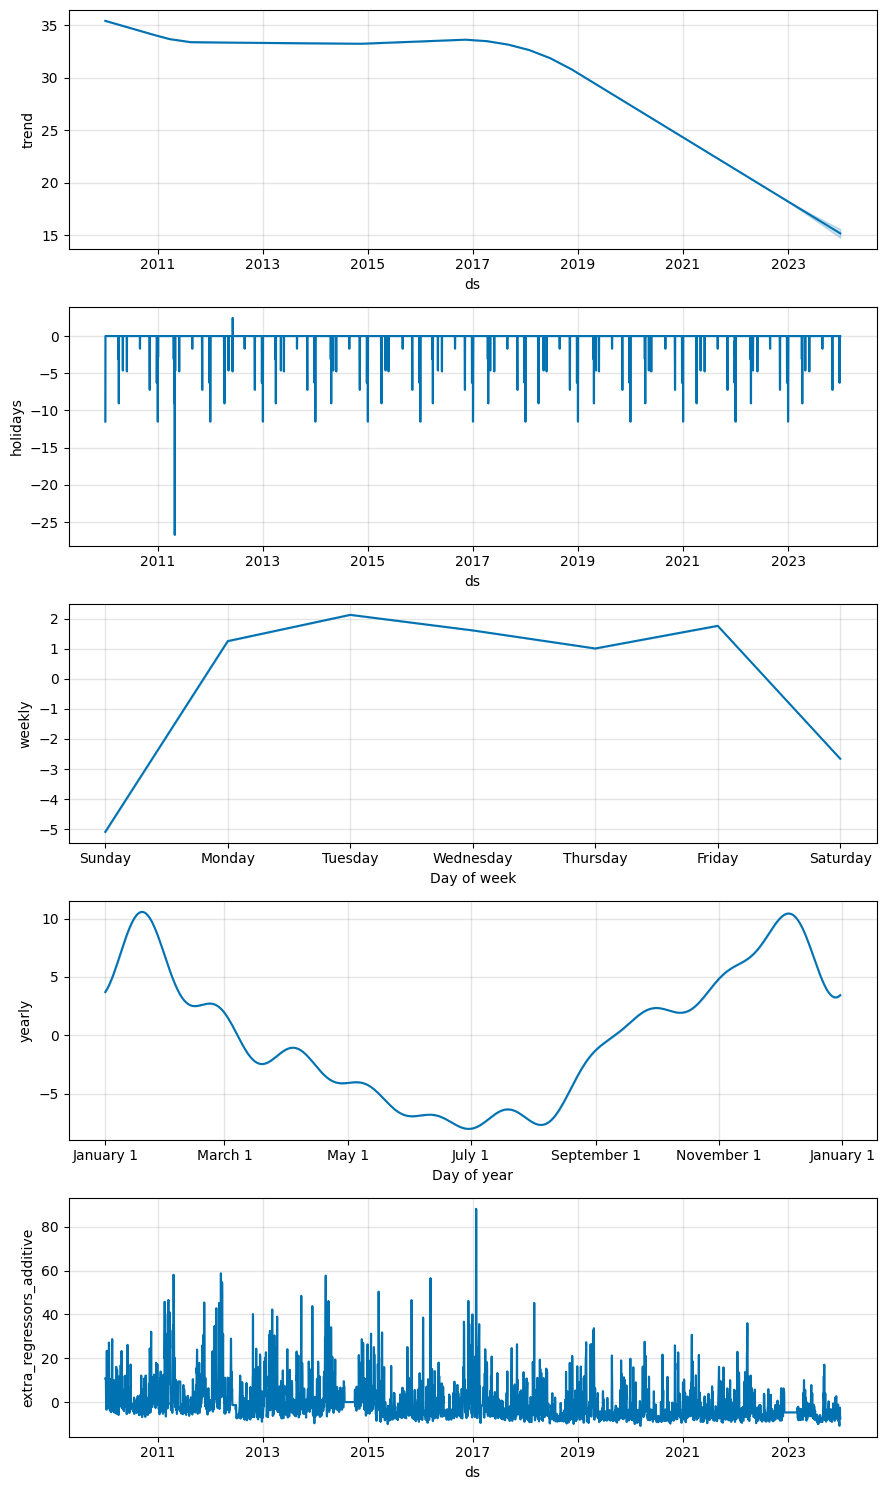

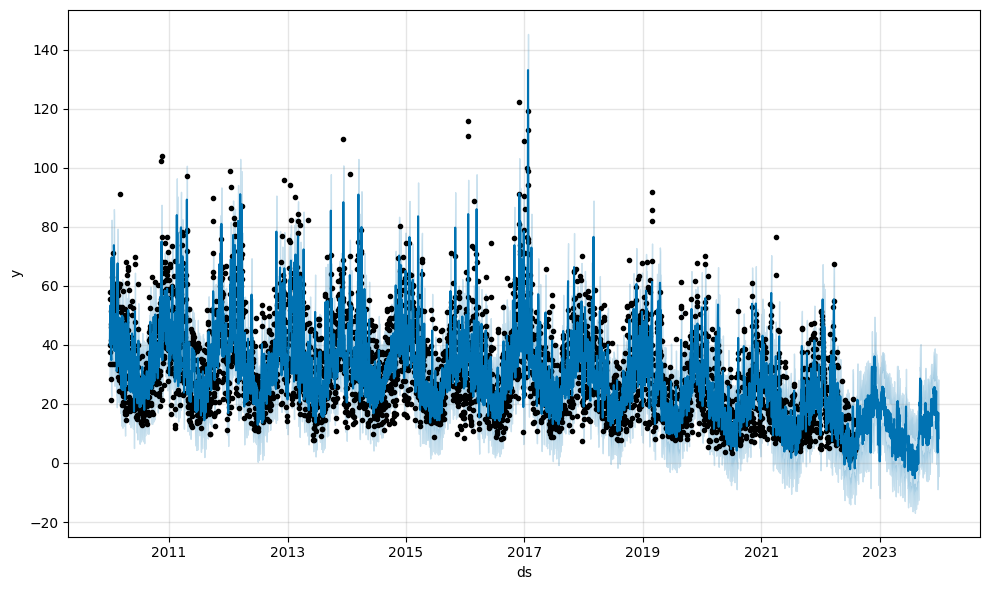

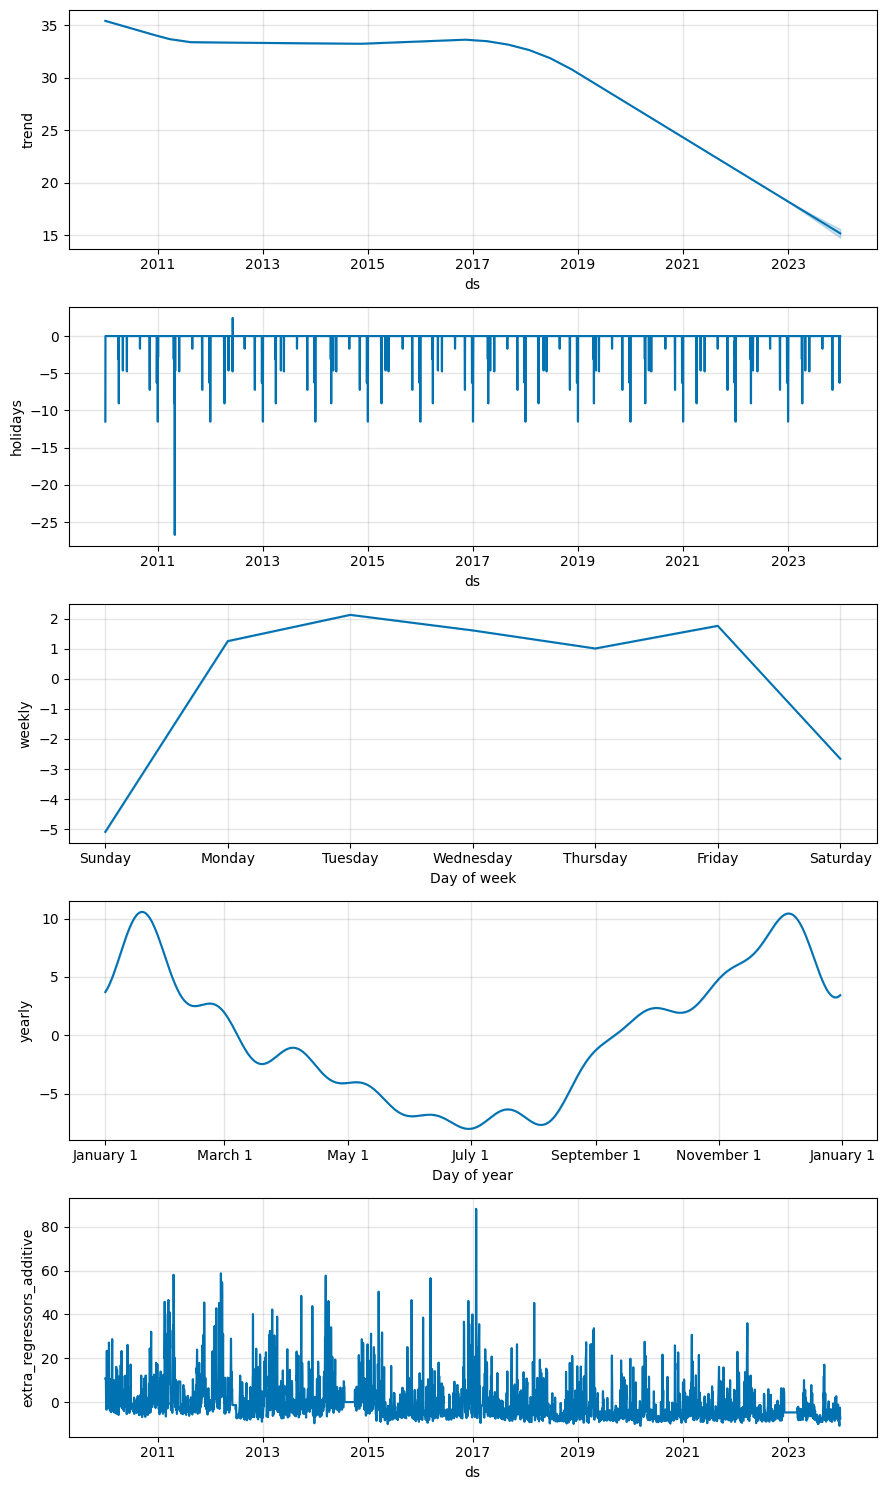

In [27]:
import pandas as pd
from prophet import Prophet
from prophet.make_holidays import make_holidays_df

# Load air quality dataset
air_quality_data = pd.read_csv('london_air_quality_2010_2023_top5_sites.csv',parse_dates=['datetime'])

# Filter for Kensington and keep 'datetime', target ('no2_level'), and regressor ('pm25_level')
kensington_no2_pm25 = air_quality_data[
                     air_quality_data["SiteName"] == "Kensington and Chelsea - North Ken"][["datetime", "no2_level","pm25_level"]]

# Resampliing as daily & Interpolate missing values for target and regressor
kensington_no2_pm25: pd.DataFrame = kensington_no2_pm25.set_index("datetime")
kensington_no2_pm25["no2_level"] = kensington_no2_pm25["no2_level"].interpolate(method="time")
kensington_no2_pm25 = (
    kensington_no2_pm25
    .resample("D")
    .mean().reset_index()
)
kensington_no2_pm25["pm25_level"] = kensington_no2_pm25["pm25_level"].bfill() .interpolate(method='linear')

# Rename to Prophet's expected column names ('ds' and 'y')
kensington_no2_pm25: pd.DataFrame = kensington_no2_pm25.rename(columns={'datetime': 'ds', 'no2_level': 'y'})

# Time-Series Train-Test Split (90% Train, 10% Test)
split_idx = int(len(kensington_no2_pm25) * 0.90)
train_df = kensington_no2_pm25.iloc[:split_idx].copy()
test_df = kensington_no2_pm25.iloc[split_idx:].copy()

# Fetch official UK / England Bank Holidays & additional events
year_list: list[int] = list(range(2010, 2024))
uk_holidays = make_holidays_df(year_list=year_list, country="UK", province="ENG")
bonfire_nights = pd.DataFrame({
  'holiday': 'bonfire_night',
  'ds': pd.to_datetime(['2010-11-05', '2011-11-05','2012-11-05', '2013-11-05','2014-11-05', '2015-11-05','2016-11-05', 
                        '2017-11-05','2018-11-05', '2019-11-05','2020-11-05', '2021-11-05', '2022-11-05', '2023-11-05' ]),
  'lower_window': 0,
  'upper_window': 1, # Captures smoke lingering overnight
})
    ##  Combine both holiday sources into a single DataFrame
lon_holidays = (
    pd.concat([uk_holidays, bonfire_nights], ignore_index=True)
    .sort_values("ds")
    .reset_index(drop=True)
)
# Initialize & Fit Prophet (on Train Set Only)
model_uk: Prophet = Prophet(
                            yearly_seasonality=True,
                            weekly_seasonality=True,
                            daily_seasonality=False,
                            changepoint_prior_scale=0.05,  # controls trend flexibility
                            holidays=lon_holidays
)
# Add regressor
model_uk.add_regressor('pm25_level')
model_uk.fit(train_df)  

# Predicting on combined train + test data
future_uk: pd.DataFrame = kensington_no2_pm25[['ds', 'pm25_level']].copy()
forecast_uk: pd.DataFrame = model_uk.predict(future_uk)

model_uk.plot(forecast_uk)
model_uk.plot_components(forecast_uk) 

